# CNN no Fashion-MNIST: Baseline e Exploração de Hiperparâmetros

> Atividade: treinar um modelo baseline, executar 6 variações de hiperparâmetros e comparar desempenho (acurácia e tempo).

In [11]:
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


In [12]:
# Carrega os dados (já vai fazer download automático, se necessário)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print('Treino:', x_train.shape, y_train.shape)
print('Teste :', x_test.shape, y_test.shape)

# Normalização e adição do canal
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Separação treino/validação (80/20 sobre o conjunto de treino original)
x_train_full, y_train_full = x_train, y_train
val_size = int(0.2 * len(x_train_full))

x_val = x_train_full[:val_size]
y_val = y_train_full[:val_size]
x_train = x_train_full[val_size:]
y_train = y_train_full[val_size:]

print('Treino final   :', x_train.shape, y_train.shape)
print('Validação final:', x_val.shape, y_val.shape)
print('Teste final    :', x_test.shape, y_test.shape)

Treino: (60000, 28, 28) (60000,)
Teste : (10000, 28, 28) (10000,)
Treino final   : (48000, 28, 28, 1) (48000,)
Validação final: (12000, 28, 28, 1) (12000,)
Teste final    : (10000, 28, 28, 1) (10000,)


## Treinamento Baseline
Arquitetura mínima solicitada:
- Conv2D (32, 3x3, ReLU)
- MaxPooling2D (2x2)
- Conv2D (64, 3x3, ReLU)
- MaxPooling2D (2x2)
- Flatten
- Dense (128, ReLU)
- Dense (10, Softmax)

Treino por 10 épocas.

In [13]:
def build_cnn(filters=(32, 64), activation='relu', input_shape=(28, 28, 1), n_classes=10):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(filters[0], (3, 3), activation=activation, padding='same', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(filters[1], (3, 3), activation=activation, padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation=activation),
        tf.keras.layers.Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def train_and_evaluate(cfg, epochs=10, verbose=0):
    model = build_cnn(filters=cfg['filters'], activation=cfg['activation'])

    start = time.time()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=cfg['batch_size'],
        verbose=verbose
    )
    elapsed = time.time() - start
    sec_per_epoch = elapsed / epochs

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    cm = confusion_matrix(y_test, y_pred)

    row = {
        'nome': cfg['nome'],
        'batch_size': cfg['batch_size'],
        'filters': f"{cfg['filters'][0]}/{cfg['filters'][1]}",
        'activation': cfg['activation'],
        'train_acc': float(train_acc),
        'val_acc': float(val_acc),
        'test_acc': float(test_acc),
        'tempo_total_s': float(elapsed),
        'tempo_por_epoca_s': float(sec_per_epoch),
    }
    return row, model, history, cm

In [14]:
baseline_cfg = {
    'nome': 'baseline',
    'batch_size': 32,
    'filters': (32, 64),
    'activation': 'relu'
}

baseline_row, baseline_model, baseline_history, cm_baseline = train_and_evaluate(
    baseline_cfg,
    epochs=10,
    verbose=1
 )

baseline_df = pd.DataFrame([baseline_row])
baseline_df

c:\Users\gustavo.telles\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.8488 - loss: 0.4203 - val_accuracy: 0.8916 - val_loss: 0.3084
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.9002 - loss: 0.2737 - val_accuracy: 0.9046 - val_loss: 0.2569
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9185 - loss: 0.2255 - val_accuracy: 0.9117 - val_loss: 0.2378
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9315 - loss: 0.1901 - val_accuracy: 0.9130 - val_loss: 0.2315
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9434 - loss: 0.1576 - val_accuracy: 0.9129 - val_loss: 0.2355
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.9529 - loss: 0.1305 - val_accuracy: 0.9186 - val_loss: 0.2371
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9629 - loss: 0.1077 - val_accuracy: 0.9132 - val_loss: 0.2630
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.9678 -

,nome,batch_size,filters,activation,train_acc,val_acc,test_acc,tempo_total_s,tempo_por_epoca_s
0,baseline,32,32/64,relu,0.976313,0.914,0.9089,361.571486,36.157149


## Exploração de Hiperparâmetros (6 variações)
Variações consideradas:
- Batch size: 32 e 128
- Filtros nos blocos: (32, 64) e (64, 128)
- Ativação: ReLU e Tanh

Obs.: foram selecionadas 6 combinações para atender ao enunciado.

In [15]:
configs = [
    {'nome': 'v1_bs32_f32-64_relu',   'batch_size': 32,  'filters': (32, 64),  'activation': 'relu'},
    {'nome': 'v2_bs128_f32-64_relu',  'batch_size': 128, 'filters': (32, 64),  'activation': 'relu'},
    {'nome': 'v3_bs32_f64-128_relu',  'batch_size': 32,  'filters': (64, 128), 'activation': 'relu'},
    {'nome': 'v4_bs128_f64-128_relu', 'batch_size': 128, 'filters': (64, 128), 'activation': 'relu'},
    {'nome': 'v5_bs32_f32-64_tanh',   'batch_size': 32,  'filters': (32, 64),  'activation': 'tanh'},
    {'nome': 'v6_bs128_f64-128_tanh', 'batch_size': 128, 'filters': (64, 128), 'activation': 'tanh'},
]

results = []
trained_models = {}
conf_mats = {}

for cfg in configs:
    print(f"Treinando {cfg['nome']}...")
    row, model, history, cm = train_and_evaluate(cfg, epochs=10, verbose=0)
    results.append(row)
    trained_models[cfg['nome']] = model
    conf_mats[cfg['nome']] = cm

df_results = pd.DataFrame(results)
df_results

Treinando v1_bs32_f32-64_relu...


c:\Users\gustavo.telles\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinando v2_bs128_f32-64_relu...


c:\Users\gustavo.telles\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinando v3_bs32_f64-128_relu...


...

Treinando v5_bs32_f32-64_tanh...


c:\Users\gustavo.telles\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Treinando v6_bs128_f64-128_tanh...


c:\Users\gustavo.telles\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,nome,batch_size,filters,activation,train_acc,val_acc,test_acc,tempo_total_s,tempo_por_epoca_s
0,v1_bs32_f32-64_relu,32,32/64,relu,0.975250,0.906917,0.9010,296.360331,29.636033
1,v2_bs128_f32-64_relu,128,32/64,relu,0.956604,0.922583,0.9114,177.718408,17.771841
2,v3_bs32_f64-128_relu,32,64/128,relu,0.980604,0.911917,0.9043,649.642654,64.964265
3,v4_bs128_f64-128_relu,128,64/128,relu,0.964792,0.919167,0.9145,484.745288,48.474529
4,v5_bs32_f32-64_tanh,32,32/64,tanh,0.978979,0.914167,0.9091,292.438469,29.243847
5,v6_bs128_f64-128_tanh,128,64/128,tanh,0.979083,0.908417,0.9016,509.578970,50.957897


In [16]:
# Tabela resumo: baseline + 6 variações
summary = pd.concat([baseline_df, df_results], ignore_index=True)

# Heurística simples de equilíbrio entre desempenho e tempo
summary['score_equilibrio'] = (
    0.7 * summary['val_acc'] + 0.3 * summary['test_acc'] - 0.02 * summary['tempo_por_epoca_s']
 )

summary_sorted = summary.sort_values('score_equilibrio', ascending=False).reset_index(drop=True)
summary_sorted

,nome,batch_size,filters,activation,train_acc,val_acc,test_acc,tempo_total_s,tempo_por_epoca_s,score_equilibrio
0,v2_bs128_f32-64_relu,128,32/64,relu,0.956604,0.922583,0.9114,177.718408,17.771841,0.563792
1,v5_bs32_f32-64_tanh,32,32/64,tanh,0.978979,0.914167,0.9091,292.438469,29.243847,0.327770
2,v1_bs32_f32-64_relu,32,32/64,relu,0.975250,0.906917,0.9010,296.360331,29.636033,0.312421
3,baseline,32,32/64,relu,0.976313,0.914000,0.9089,361.571486,36.157149,0.189327
4,v4_bs128_f64-128_relu,128,64/128,relu,0.964792,0.919167,0.9145,484.745288,48.474529,-0.051724
5,v6_bs128_f64-128_tanh,128,64/128,tanh,0.979083,0.908417,0.9016,509.578970,50.957897,-0.112786
6,v3_bs32_f64-128_relu,32,64/128,relu,0.980604,0.911917,0.9043,649.642654,64.964265,-0.389654


Melhor configuração (equilíbrio): v2_bs128_f32-64_relu


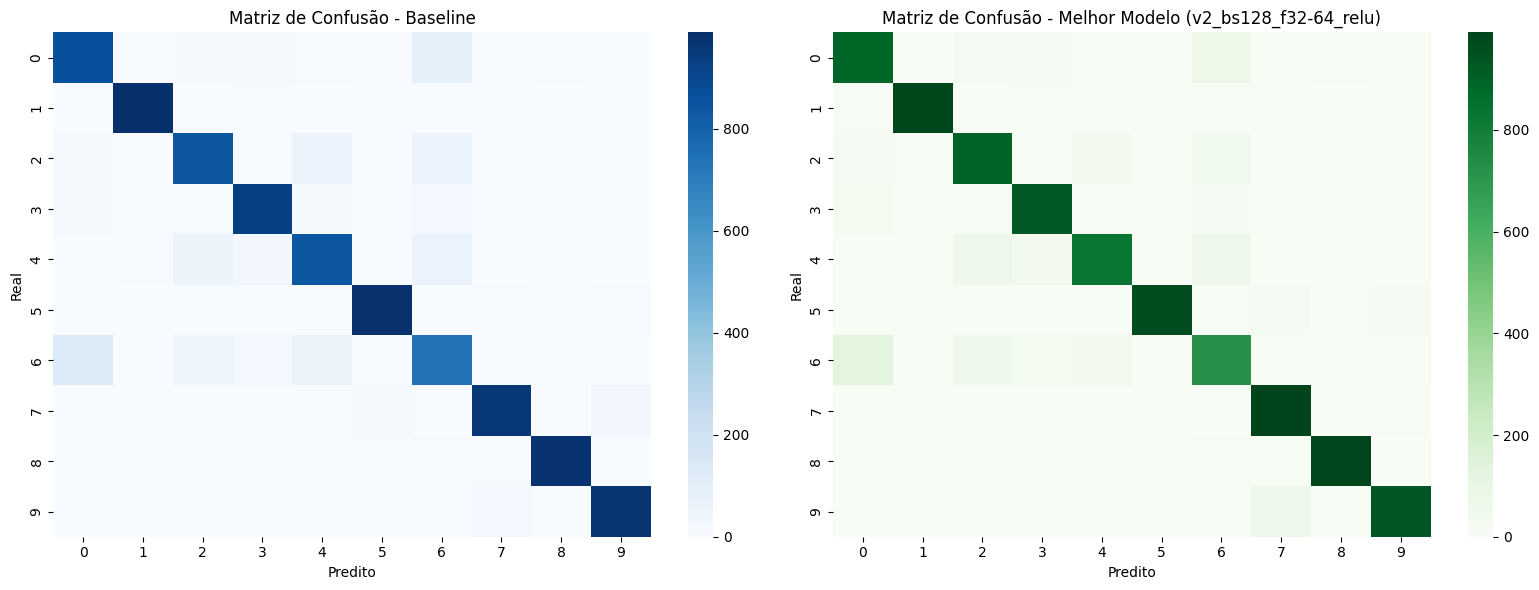

In [17]:
# Seleção do melhor modelo pelo score de equilíbrio
best_name = summary_sorted.loc[0, 'nome']
print('Melhor configuração (equilíbrio):', best_name)

if best_name == 'baseline':
    cm_best = cm_baseline
    best_model = baseline_model
else:
    cm_best = conf_mats[best_name]
    best_model = trained_models[best_name]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_baseline, annot=False, cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusão - Baseline')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

sns.heatmap(cm_best, annot=False, cmap='Greens', ax=axes[1])
axes[1].set_title(f'Matriz de Confusão - Melhor Modelo ({best_name})')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

In [18]:
# Respostas finais da atividade
relu_mean = summary[summary['activation'] == 'relu']['test_acc'].mean()
tanh_mean = summary[summary['activation'] == 'tanh']['test_acc'].mean()

small_filters_mean = summary[summary['filters'] == '32/64']['test_acc'].mean()
large_filters_mean = summary[summary['filters'] == '64/128']['test_acc'].mean()

best_row = summary_sorted.iloc[0]

print('=== COMPARAÇÃO FINAL ===')
print()
print(f"1) Melhor equilíbrio entre acurácia e tempo: {best_row['nome']}")
print(f"   - Val acc : {best_row['val_acc']:.4f}")
print(f"   - Test acc: {best_row['test_acc']:.4f}")
print(f"   - Tempo/época: {best_row['tempo_por_epoca_s']:.2f} s")
print()
print('2) Diferença ReLU x Tanh (média de test_acc):')
print(f"   - ReLU: {relu_mean:.4f}")
print(f"   - Tanh: {tanh_mean:.4f}")
if abs(relu_mean - tanh_mean) < 0.01:
    print('   - Diferença pequena (menos de 1 ponto percentual).')
else:
    print('   - Diferença relevante (maior ou igual a 1 ponto percentual).')
print()
print('3) Efeito de aumentar o número de filtros (média de test_acc):')
print(f"   - Filtros 32/64 : {small_filters_mean:.4f}")
print(f"   - Filtros 64/128: {large_filters_mean:.4f}")
if large_filters_mean > small_filters_mean:
    print('   - Aumento de filtros melhorou a acurácia média.')
else:
    print('   - Aumento de filtros não trouxe ganho médio de acurácia.')

print()
print('Tabela comparativa final:')
summary_sorted

=== COMPARAÇÃO FINAL ===

1) Melhor equilíbrio entre acurácia e tempo: v2_bs128_f32-64_relu
   - Val acc : 0.9226
   - Test acc: 0.9114
   - Tempo/época: 17.77 s

2) Diferença ReLU x Tanh (média de test_acc):
   - ReLU: 0.9080
   - Tanh: 0.9053
   - Diferença pequena (menos de 1 ponto percentual).

3) Efeito de aumentar o número de filtros (média de test_acc):
   - Filtros 32/64 : 0.9076
   - Filtros 64/128: 0.9068
   - Aumento de filtros não trouxe ganho médio de acurácia.

Tabela comparativa final:


,nome,batch_size,filters,activation,train_acc,val_acc,test_acc,tempo_total_s,tempo_por_epoca_s,score_equilibrio
0,v2_bs128_f32-64_relu,128,32/64,relu,0.956604,0.922583,0.9114,177.718408,17.771841,0.563792
1,v5_bs32_f32-64_tanh,32,32/64,tanh,0.978979,0.914167,0.9091,292.438469,29.243847,0.327770
2,v1_bs32_f32-64_relu,32,32/64,relu,0.975250,0.906917,0.9010,296.360331,29.636033,0.312421
3,baseline,32,32/64,relu,0.976313,0.914000,0.9089,361.571486,36.157149,0.189327
4,v4_bs128_f64-128_relu,128,64/128,relu,0.964792,0.919167,0.9145,484.745288,48.474529,-0.051724
5,v6_bs128_f64-128_tanh,128,64/128,tanh,0.979083,0.908417,0.9016,509.578970,50.957897,-0.112786
6,v3_bs32_f64-128_relu,32,64/128,relu,0.980604,0.911917,0.9043,649.642654,64.964265,-0.389654
